# Gasoline Price Pass-Through — Step 1: Data Collection

This notebook collects **all raw data** from two free APIs:
- **EIA API** (U.S. Energy Information Administration) — gasoline prices, crude oil, refinery data, inventories
- **FRED API** (Federal Reserve Economic Data) — crude oil prices, USD exchange rate, CPI, consumer sentiment

**Before running this notebook, you need two free API keys (2 min each):**

1. **EIA API key** → Go to https://www.eia.gov/opendata/register.php → fill the form → you'll get the key immediately via email
2. **FRED API key** → Go to https://fred.stlouisfed.org/docs/api/api_key.html → click "Request API Key" → create a free account → key is shown on screen

Once you have both keys, paste them in the cell below and run the notebook top to bottom.

---
## 0. Setup

In [1]:
# Install required packages (run once)
!pip install requests pandas fredapi --quiet

In [2]:
# ============================================================
# PASTE YOUR API KEYS HERE
# ============================================================

EIA_API_KEY = "5OICRhvYxqjyIgoecg3gcrqFa263hLwj488ZP2gi"
FRED_API_KEY = "728dfb38cda4e038d9ef718e6598945a"

# ============================================================
# Quick validation
# ============================================================
assert EIA_API_KEY != "PASTE_YOUR_EIA_KEY_HERE", "⚠️ Please paste your EIA API key above"
assert FRED_API_KEY != "PASTE_YOUR_FRED_KEY_HERE", "⚠️ Please paste your FRED API key above"
print(" Both API keys are set.")

 Both API keys are set.


In [3]:
import requests
import pandas as pd
import numpy as np
import time
import os
from pathlib import Path
from datetime import datetime

# Create folders to store raw data
Path("data/raw/eia").mkdir(parents=True, exist_ok=True)
Path("data/raw/fred").mkdir(parents=True, exist_ok=True)

print(" Imports done. Folders created.")
print(f"   Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 Imports done. Folders created.
   Timestamp: 2026-04-06 16:10:26


---
## 1. Helper Functions

These two functions handle all the API calls. You don't need to modify them.

In [4]:
def fetch_eia(endpoint, params, name):
    """
    Fetch data from the EIA API v2.
    Handles pagination automatically.
    Saves raw CSV to data/raw/eia/
    """
    url = f"https://api.eia.gov/v2{endpoint}"
    params["api_key"] = EIA_API_KEY
    
    # EIA API needs repeated keys for list values
    flat_params = []
    for key, value in params.items():
        if isinstance(value, list):
            for v in value:
                flat_params.append((key, v))
        else:
            flat_params.append((key, value))
    
    all_data = []
    offset = 0
    limit = int(params.get("length", 5000))
    
    print(f"  Fetching {name}...", end=" ")
    
    while True:
        request_params = flat_params + [("offset", offset)]
        response = requests.get(url, params=request_params)
        
        if response.status_code != 200:
            print(f" Error {response.status_code}")
            print(f"  Response: {response.text[:300]}")
            return pd.DataFrame()
        
        data = response.json()
        records = data.get("response", {}).get("data", [])
        
        if not records:
            break
        
        all_data.extend(records)
        
        total = int(data.get("response", {}).get("total", 0))
        if len(all_data) >= total or len(records) < limit:
            break
        
        offset += limit
        time.sleep(0.3)  # be nice to the API
    
    if not all_data:
        print("⚠️ No data returned")
        return pd.DataFrame()
    
    df = pd.DataFrame(all_data)
    if "period" in df.columns:
        df["period"] = pd.to_datetime(df["period"])
    if "value" in df.columns:
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
    
    # Save raw
    filepath = f"data/raw/eia/{name}.csv"
    df.to_csv(filepath, index=False)
    print(f" {len(df)} records → {filepath}")
    
    return df

In [5]:
def fetch_fred(series_id, start_date="2000-01-01"):
    """
    Fetch a single series from the FRED API.
    Saves raw CSV to data/raw/fred/
    """
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": start_date,
        "sort_order": "asc",
    }
    
    print(f"  Fetching {series_id}...", end=" ")
    
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f" Error {response.status_code}")
        return pd.DataFrame()
    
    data = response.json()
    observations = data.get("observations", [])
    
    if not observations:
        print("⚠ No data")
        return pd.DataFrame()
    
    df = pd.DataFrame(observations)
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df[["date", "value"]].rename(columns={"value": series_id})
    
    filepath = f"data/raw/fred/{series_id}.csv"
    df.to_csv(filepath, index=False)
    print(f" {len(df)} records → {filepath}")
    
    return df

---
## 2. Collect EIA Data

We're pulling 5 datasets from the EIA. Each one is a different piece of the gasoline supply chain.

| Dataset | What it tells us | Why we need it |
|---------|-----------------|----------------|
| Retail gas prices | What consumers pay at the pump, by region | This is our target variable |
| Spot/wholesale prices | What refineries sell gasoline for | Needed to calculate refinery margins |
| Crude oil prices | Cost of raw material | Primary driver of gas prices |
| Refinery utilization | How much refining capacity is in use | Supply-side signal |
| Gasoline stocks | How much gasoline is sitting in storage | Inventory signal |

### 2.1 Retail Gasoline Prices (by PADD Region)

Weekly retail prices for regular gasoline across all 5 PADD regions + national average.  
PADDs are how the U.S. divides its petroleum supply districts:
- PADD 1 = East Coast
- PADD 2 = Midwest  
- PADD 3 = Gulf Coast
- PADD 4 = Rocky Mountain
- PADD 5 = West Coast

In [6]:
retail_gas = fetch_eia(
    endpoint="/petroleum/pri/gnd/data/",
    params={
        "frequency": "weekly",
        "data[0]": "value",
        "facets[product][]":  "EPM0",          # Regular gasoline
        "facets[duoarea][]":  ["R10", "R20", "R30", "R40", "R50", "NUS"],
        "sort[0][column]":   "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    },
    name="retail_gasoline_prices"
)

if not retail_gas.empty:
    print(f"\n  Preview:")
    print(f"  Date range: {retail_gas['period'].min()} to {retail_gas['period'].max()}")
    print(f"  Regions:    {retail_gas['duoarea'].unique().tolist() if 'duoarea' in retail_gas.columns else 'N/A'}")
    display(retail_gas.head())

  Fetching retail_gasoline_prices...  10332 records → data/raw/eia/retail_gasoline_prices.csv

  Preview:
  Date range: 1993-04-05 00:00:00 to 2026-03-30 00:00:00
  Regions:    ['NUS', 'R50', 'R40', 'R30', 'R20', 'R10']


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1993-04-05,NUS,U.S.,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_NUS_DPG,U.S. All Grades All Formulations Retail Gasoli...,1.068,$/GAL
1,1993-04-05,R50,PADD 5,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_R50_DPG,West Coast All Grades All Formulations Retail ...,1.152,$/GAL
2,1993-04-05,R40,PADD 4,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_R40_DPG,Rocky Mountain All Grades All Formulations Ret...,1.093,$/GAL
3,1993-04-05,R30,PADD 3,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_R30_DPG,Gulf Coast All Grades All Formulations Retail ...,1.064,$/GAL
4,1993-04-05,R20,PADD 2,EPM0,Total Gasoline,PTE,Retail Sales,EMM_EPM0_PTE_R20_DPG,Midwest All Grades All Formulations Retail Gas...,1.061,$/GAL


### 2.2 Spot Prices (Crude Oil + Wholesale Gasoline)

These are the wholesale/market prices — not what consumers pay, but what the industry trades at.  
We need both crude oil spot and gasoline spot to calculate the **crack spread** (refinery profit margin).

In [7]:
spot_prices = fetch_eia(
    endpoint="/petroleum/pri/spt/data/",
    params={
        "frequency": "weekly",
        "data[0]": "value",
        "facets[series][]":  [
            "RWTC",                         # WTI Crude Oil ($/barrel)
            "EER_EPMRU_PF4_RGC_DPG",        # Gulf Coast Conventional Gasoline ($/gal)
            "EER_EPMRU_PF4_Y35NY_DPG",      # NY Harbor Conventional Gasoline ($/gal)
        ],
        "sort[0][column]":   "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    },
    name="spot_prices"
)

if not spot_prices.empty:
    print(f"\n  Preview:")
    print(f"  Date range: {spot_prices['period'].min()} to {spot_prices['period'].max()}")
    print(f"  Series:     {spot_prices['series'].unique().tolist() if 'series' in spot_prices.columns else 'N/A'}")
    display(spot_prices.head())

  Fetching spot_prices...  6256 records → data/raw/eia/spot_prices.csv

  Preview:
  Date range: 1986-01-03 00:00:00 to 2026-03-27 00:00:00
  Series:     ['RWTC', 'EER_EPMRU_PF4_RGC_DPG', 'EER_EPMRU_PF4_Y35NY_DPG']


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1986-01-03,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",25.78,$/BBL
1,1986-01-10,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",25.99,$/BBL
2,1986-01-17,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",24.57,$/BBL
3,1986-01-24,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",20.31,$/BBL
4,1986-01-31,YCUOK,NA,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",19.69,$/BBL


### 2.3 Refinery Utilization Rate

What percentage of total U.S. refining capacity is currently in use.  
When utilization drops (e.g., hurricane shutdowns, maintenance), supply tightens and prices can spike.

In [8]:
refinery_util = fetch_eia(
    endpoint="/petroleum/pnp/wiup/data/",
    params={
        "frequency": "weekly",
        "data[0]": "value",
        "sort[0][column]":   "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    },
    name="refinery_utilization"
)

if not refinery_util.empty:
    print(f"\n  Preview:")
    print(f"  Date range: {refinery_util['period'].min()} to {refinery_util['period'].max()}")
    if 'duoarea' in refinery_util.columns:
        print(f"  Regions:    {refinery_util['duoarea'].unique().tolist()}")
    display(refinery_util.head())

  Fetching refinery_utilization...  71810 records → data/raw/eia/refinery_utilization.csv

  Preview:
  Date range: 1982-08-20 00:00:00 to 2026-03-27 00:00:00
  Regions:    ['NUS', 'R50', 'R40', 'R30', 'R20', 'R10']


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1982-08-20,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,11722.0,MBBL/D
1,1982-08-27,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,11918.0,MBBL/D
2,1982-09-24,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,12375.0,MBBL/D
3,1982-10-01,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,12303.0,MBBL/D
4,1982-10-08,NUS,U.S.,EPC0,Crude Oil,YIY,Refinery Net Input,WCRRIUS2,U.S. Refiner Net Input of Crude Oil (Thousand ...,12062.0,MBBL/D


### 2.4 Gasoline Stocks (Inventory Levels)

How much finished gasoline is sitting in storage across the U.S.  
Low inventory = tighter supply = upward price pressure.

In [9]:
gas_stocks = fetch_eia(
    endpoint="/petroleum/stoc/wstk/data/",
    params={
        "frequency": "weekly",
        "data[0]": "value",
        "facets[product][]":  "EPM0",   # Total motor gasoline
        "sort[0][column]":   "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    },
    name="gasoline_stocks"
)

if not gas_stocks.empty:
    print(f"\n  Preview:")
    print(f"  Date range: {gas_stocks['period'].min()} to {gas_stocks['period'].max()}")
    display(gas_stocks.head())

  Fetching gasoline_stocks...  16884 records → data/raw/eia/gasoline_stocks.csv

  Preview:
  Date range: 1990-01-05 00:00:00 to 2026-03-27 00:00:00


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1990-01-05,R10,PADD 1,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTP11,East Coast (PADD 1) Ending Stocks of Total Gas...,55589,MBBL
1,1990-01-05,NUS,U.S.,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTUS1,U.S. Ending Stocks of Total Gasoline (Thousand...,210982,MBBL
2,1990-01-05,R50,PADD 5,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTP51,West Coast (PADD 5) Ending Stocks of Total Gas...,30618,MBBL
3,1990-01-05,R40,PADD 4,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTP41,Rocky Mountain (PADD 4) Ending Stocks of Total...,7530,MBBL
4,1990-01-05,R30,PADD 3,EPM0,Total Gasoline,SAE,Ending Stocks,WGTSTP31,Gulf Coast (PADD 3) Ending Stocks of Total Gas...,59964,MBBL


### 2.5 Futures Prices (NYMEX)

What the market *expects* crude oil and gasoline to cost in the near future.  
This is a forward-looking signal — if futures spike, retail prices often follow.

In [10]:
futures = fetch_eia(
    endpoint="/petroleum/pri/fut/data/",
    params={
        "frequency": "weekly",
        "data[0]": "value",
        "facets[series][]":  [
            "RCLC1",    # Crude oil futures (front-month)
            "RCLC2",    # Crude oil futures (second-month)
        ],
        "sort[0][column]":   "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    },
    name="futures_prices"
)

if not futures.empty:
    print(f"\n  Preview:")
    print(f"  Date range: {futures['period'].min()} to {futures['period'].max()}")
    print(f"  Series:     {futures['series'].unique().tolist() if 'series' in futures.columns else 'N/A'}")
    display(futures.head())

  Fetching futures_prices...  4189 records → data/raw/eia/futures_prices.csv

  Preview:
  Date range: 1983-04-08 00:00:00 to 2024-04-05 00:00:00
  Series:     ['RCLC1', 'RCLC2']


,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,1983-04-08,YCUOK,NA,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",29.92,$/BBL
1,1983-04-15,YCUOK,NA,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",30.61,$/BBL
2,1983-04-22,YCUOK,NA,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",30.73,$/BBL
3,1983-04-29,YCUOK,NA,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",30.74,$/BBL
4,1983-05-06,YCUOK,NA,EPC0,Crude Oil,PE1,Future Contract 1,RCLC1,"Cushing, OK Crude Oil Future Contract 1 (Dolla...",30.44,$/BBL


---
## 3. Collect FRED Data

These are macroeconomic indicators that may influence gasoline pricing.

| Series ID | What it is | Why we need it |
|-----------|-----------|----------------|
| DCOILWTICO | WTI Crude Oil daily price | Cross-reference with EIA crude data |
| DCOILBRENTEU | Brent Crude Oil daily price | International benchmark |
| DTWEXBGS | Trade-weighted USD index | Stronger dollar = cheaper imports |
| CPIAUCSL | Consumer Price Index | Inflation context |
| UMCSENT | Consumer Sentiment | Demand-side psychology |
| DFF | Federal Funds Rate | Monetary policy context |
| GASREGW | Weekly U.S. gas price (FRED version) | Cross-validation with EIA data |

In [11]:
fred_series = {
    "DCOILWTICO":  "WTI Crude Oil Price (daily)",
    "DCOILBRENTEU": "Brent Crude Oil Price (daily)",
    "DTWEXBGS":    "Trade Weighted USD Index",
    "CPIAUCSL":    "Consumer Price Index (monthly)",
    "UMCSENT":     "Consumer Sentiment (monthly)",
    "DFF":         "Federal Funds Rate (daily)",
    "GASREGW":     "U.S. Regular Gas Price (weekly)",
}

fred_dataframes = {}

print("Fetching FRED data...\n")
for series_id, description in fred_series.items():
    df = fetch_fred(series_id)
    if not df.empty:
        fred_dataframes[series_id] = df
    time.sleep(0.3)

Fetching FRED data...

  Fetching DCOILWTICO...  6846 records → data/raw/fred/DCOILWTICO.csv
  Fetching DCOILBRENTEU...  6846 records → data/raw/fred/DCOILBRENTEU.csv
  Fetching DTWEXBGS...  5280 records → data/raw/fred/DTWEXBGS.csv
  Fetching CPIAUCSL...  314 records → data/raw/fred/CPIAUCSL.csv
  Fetching UMCSENT...  314 records → data/raw/fred/UMCSENT.csv
  Fetching DFF...  9589 records → data/raw/fred/DFF.csv
  Fetching GASREGW...  1370 records → data/raw/fred/GASREGW.csv


In [12]:
# Quick look at one FRED series
if "DCOILWTICO" in fred_dataframes:
    print("Sample — WTI Crude Oil Price:")
    display(fred_dataframes["DCOILWTICO"].tail(10))

Sample — WTI Crude Oil Price:


,date,DCOILWTICO
6836,2026-03-17,96.01
6837,2026-03-18,96.12
6838,2026-03-19,96.11
6839,2026-03-20,98.71
6840,2026-03-23,89.33
6841,2026-03-24,93.18
6842,2026-03-25,91.51
6843,2026-03-26,96.18
6844,2026-03-27,101.26
6845,2026-03-30,104.69


---
## 4. Data Collection Summary

Let's verify what we got.

In [13]:
print("=" * 65)
print("DATA COLLECTION SUMMARY")
print("=" * 65)

# EIA datasets
eia_datasets = {
    "Retail Gasoline Prices": retail_gas,
    "Spot Prices (Crude + Gasoline)": spot_prices,
    "Refinery Utilization": refinery_util,
    "Gasoline Stocks": gas_stocks,
    "Futures Prices": futures,
}

print("\n EIA Data:")
print(f"{'Dataset':<35} {'Rows':>8} {'Columns':>8}  {'Date Range'}")
print("-" * 85)
for name, df in eia_datasets.items():
    if df.empty:
        print(f"{name:<35} {'EMPTY':>8} {'—':>8}  —")
    else:
        date_min = df['period'].min().strftime('%Y-%m-%d') if 'period' in df.columns else '?'
        date_max = df['period'].max().strftime('%Y-%m-%d') if 'period' in df.columns else '?'
        print(f"{name:<35} {len(df):>8} {len(df.columns):>8}  {date_min} → {date_max}")

print(f"\n FRED Data:")
print(f"{'Series':<15} {'Description':<35} {'Rows':>8}  {'Date Range'}")
print("-" * 85)
for series_id, description in fred_series.items():
    if series_id in fred_dataframes:
        df = fred_dataframes[series_id]
        date_min = df['date'].min().strftime('%Y-%m-%d')
        date_max = df['date'].max().strftime('%Y-%m-%d')
        print(f"{series_id:<15} {description:<35} {len(df):>8}  {date_min} → {date_max}")
    else:
        print(f"{series_id:<15} {description:<35} {'MISSING':>8}  —")

# Count files saved
eia_files = list(Path("data/raw/eia").glob("*.csv"))
fred_files = list(Path("data/raw/fred").glob("*.csv"))
print(f"\n📁 Files saved:")
print(f"   data/raw/eia/  → {len(eia_files)} files")
print(f"   data/raw/fred/ → {len(fred_files)} files")
print(f"\n{'=' * 65}")

DATA COLLECTION SUMMARY

 EIA Data:
Dataset                                 Rows  Columns  Date Range
-------------------------------------------------------------------------------------
Retail Gasoline Prices                 10332       11  1993-04-05 → 2026-03-30
Spot Prices (Crude + Gasoline)          6256       11  1986-01-03 → 2026-03-27
Refinery Utilization                   71810       11  1982-08-20 → 2026-03-27
Gasoline Stocks                        16884       11  1990-01-05 → 2026-03-27
Futures Prices                          4189       11  1983-04-08 → 2024-04-05

 FRED Data:
Series          Description                             Rows  Date Range
-------------------------------------------------------------------------------------
DCOILWTICO      WTI Crude Oil Price (daily)             6846  2000-01-03 → 2026-03-30
DCOILBRENTEU    Brent Crude Oil Price (daily)           6846  2000-01-03 → 2026-03-30
DTWEXBGS        Trade Weighted USD Index                5280  2006-01-02 

---
## 5. Quick Sanity Check

Let's do a fast visual check that the data looks reasonable before moving to cleaning.

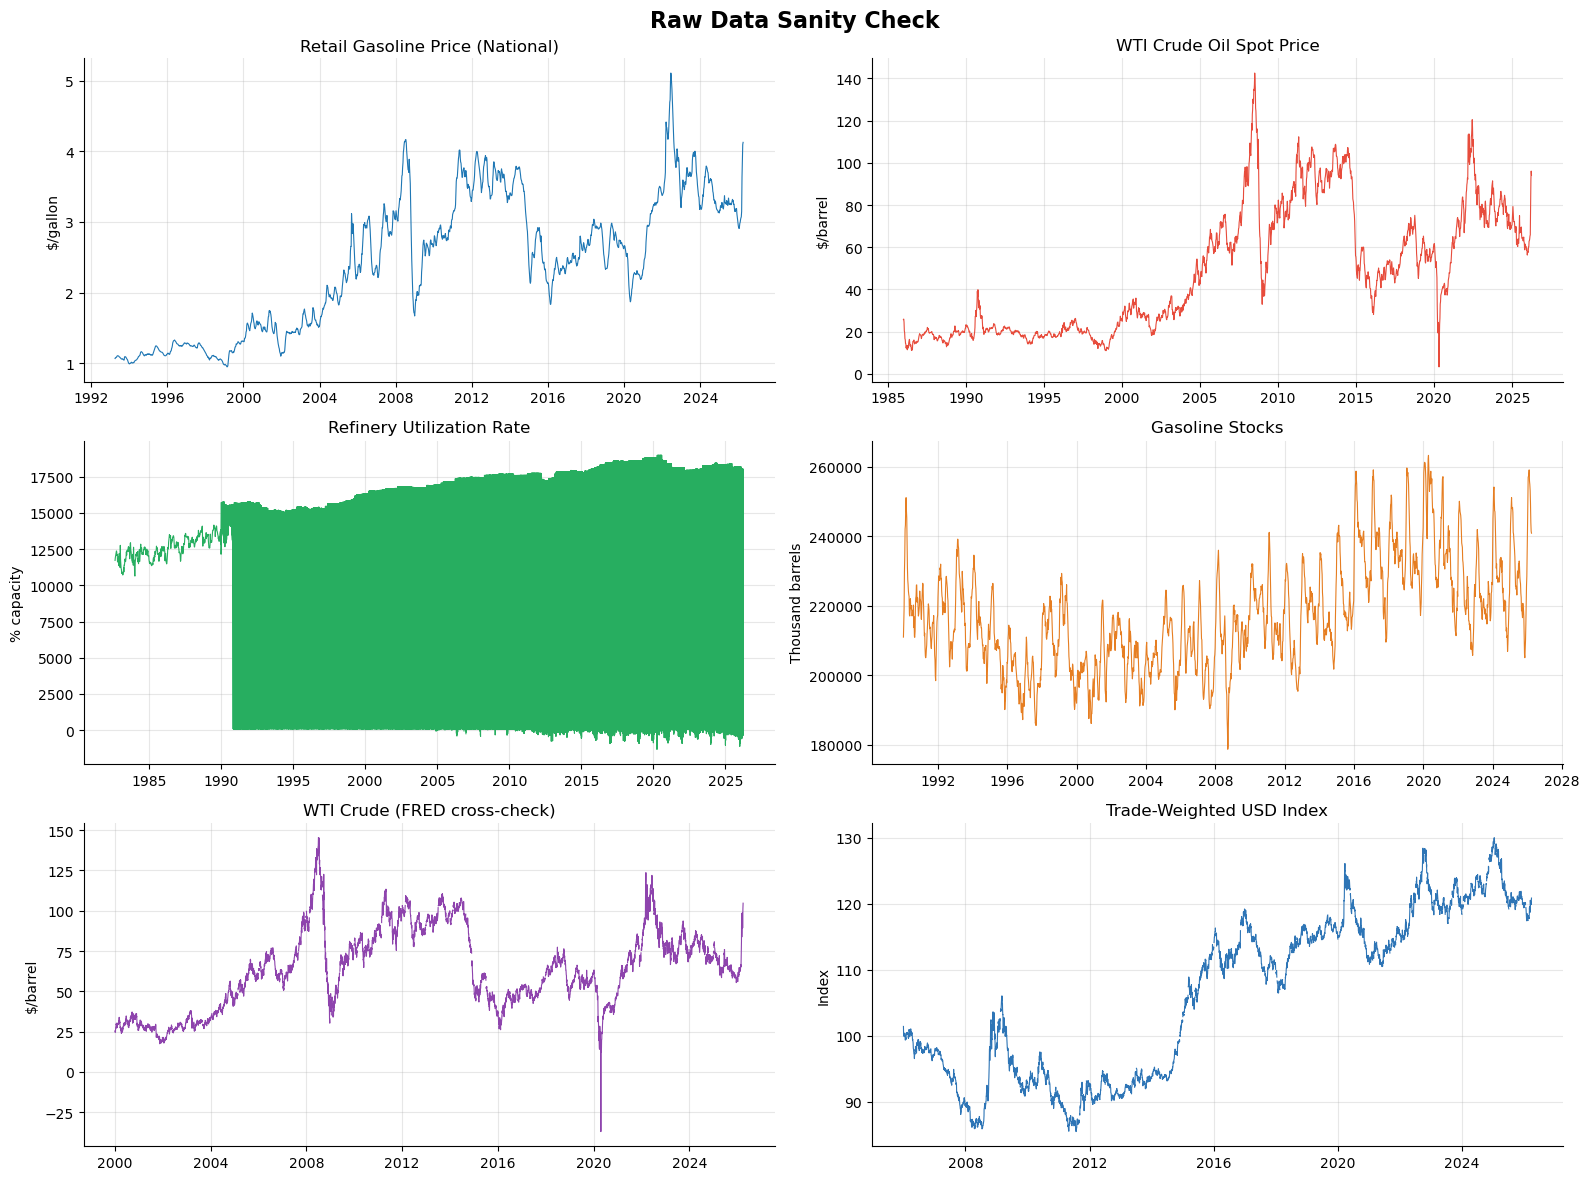


 Sanity check plot saved to data/raw/sanity_check.png


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Raw Data Sanity Check", fontsize=16, fontweight="bold")

# 1. Retail gas — national only
ax = axes[0, 0]
if not retail_gas.empty and 'duoarea' in retail_gas.columns:
    national = retail_gas[retail_gas['duoarea'] == 'NUS'].sort_values('period')
    if national.empty:
        # Try alternative: use whatever region has the most data
        national = retail_gas.sort_values('period')
    ax.plot(national['period'], national['value'], linewidth=0.8)
ax.set_title("Retail Gasoline Price (National)")
ax.set_ylabel("$/gallon")

# 2. WTI Crude from spot prices
ax = axes[0, 1]
if not spot_prices.empty and 'series' in spot_prices.columns:
    wti = spot_prices[spot_prices['series'] == 'RWTC'].sort_values('period')
    ax.plot(wti['period'], wti['value'], linewidth=0.8, color='#E74C3C')
ax.set_title("WTI Crude Oil Spot Price")
ax.set_ylabel("$/barrel")

# 3. Refinery utilization
ax = axes[1, 0]
if not refinery_util.empty:
    if 'duoarea' in refinery_util.columns:
        nat_ref = refinery_util[refinery_util['duoarea'] == 'NUS'].sort_values('period')
        if nat_ref.empty:
            nat_ref = refinery_util.sort_values('period')
    else:
        nat_ref = refinery_util.sort_values('period')
    ax.plot(nat_ref['period'], nat_ref['value'], linewidth=0.8, color='#27AE60')
ax.set_title("Refinery Utilization Rate")
ax.set_ylabel("% capacity")

# 4. Gasoline stocks
ax = axes[1, 1]
if not gas_stocks.empty:
    if 'duoarea' in gas_stocks.columns:
        nat_stocks = gas_stocks[gas_stocks['duoarea'] == 'NUS'].sort_values('period')
        if nat_stocks.empty:
            nat_stocks = gas_stocks.sort_values('period')
    else:
        nat_stocks = gas_stocks.sort_values('period')
    ax.plot(nat_stocks['period'], nat_stocks['value'], linewidth=0.8, color='#E67E22')
ax.set_title("Gasoline Stocks")
ax.set_ylabel("Thousand barrels")

# 5. FRED — WTI crude (cross-check)
ax = axes[2, 0]
if "DCOILWTICO" in fred_dataframes:
    df_wti = fred_dataframes["DCOILWTICO"]
    ax.plot(df_wti['date'], df_wti['DCOILWTICO'], linewidth=0.8, color='#8E44AD')
ax.set_title("WTI Crude (FRED cross-check)")
ax.set_ylabel("$/barrel")

# 6. FRED — USD Index
ax = axes[2, 1]
if "DTWEXBGS" in fred_dataframes:
    df_usd = fred_dataframes["DTWEXBGS"]
    ax.plot(df_usd['date'], df_usd['DTWEXBGS'], linewidth=0.8, color='#2E75B6')
ax.set_title("Trade-Weighted USD Index")
ax.set_ylabel("Index")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("data/raw/sanity_check.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Sanity check plot saved to data/raw/sanity_check.png")

---
## 6. Check for Issues

Before we move to cleaning, let's flag any potential problems.

In [15]:
print("POTENTIAL ISSUES TO ADDRESS IN CLEANING:\n")
issue_count = 0

for name, df in eia_datasets.items():
    if df.empty:
        print(f"   {name}: No data returned. Check API endpoint or parameters.")
        issue_count += 1
        continue
    
    if 'value' in df.columns:
        null_count = df['value'].isna().sum()
        null_pct = null_count / len(df) * 100
        if null_pct > 5:
            print(f"  ⚠  {name}: {null_pct:.1f}% null values ({null_count} rows)")
            issue_count += 1
        
        neg_count = (df['value'] < 0).sum()
        if neg_count > 0 and name != "Futures Prices":
            print(f"  ⚠  {name}: {neg_count} negative values found")
            issue_count += 1

for series_id, df in fred_dataframes.items():
    null_count = df[series_id].isna().sum()
    null_pct = null_count / len(df) * 100
    if null_pct > 5:
        print(f"  ⚠  FRED {series_id}: {null_pct:.1f}% null values")
        issue_count += 1

if issue_count == 0:
    print("  ✅ No major issues detected. Data looks clean for initial use.")
else:
    print(f"\n  Found {issue_count} issue(s) to address in the cleaning step.")

print("\n" + "=" * 65)
print("DATA COLLECTION COMPLETE")
print("=" * 65)

POTENTIAL ISSUES TO ADDRESS IN CLEANING:

  ⚠  Refinery Utilization: 10.3% null values (7370 rows)
  ⚠  Refinery Utilization: 6548 negative values found

  Found 2 issue(s) to address in the cleaning step.

DATA COLLECTION COMPLETE
